# Code for first figure of Section 5.8: Lottery Tickets in Other Models

In [1]:
!nvidia-smi

Thu Apr 16 15:21:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random
import torch.autograd as autograd
import math
from matplotlib import pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")
class ClassicNetwork(nn.Module):
    def __init__(self, layer_sizes,bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[z for l in layer_sizes
              for z in [nn.Linear(l[0], l[1],bias=bias), nn.ReLU()]][:-1]
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

# Set up signed Kaiming initialization.
def signed_kaiming_constant_(tensor, a=0, mode='fan_in', nonlinearity='relu', k=0.5, sparsity=0):
    fan = nn.init._calculate_correct_fan(tensor, mode)  # calculating correct fan, depends on shape and type of nn
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = (gain / math.sqrt(fan))
    # scale by (1/sqrt(k))
    if k != 0:
        std *= (1 / math.sqrt(k))
    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            mask = (torch.rand_like(tensor) > sparsity).float()  # Keeps (1 - sparsity)% weights
            tensor *= mask
        return tensor

# A function to retreive a subset of the top k% of the weights by their score.
# The gradient is estimated by the identity (i.e. it goes "straight-through").
# See the paper "What's Hidden in a Randomly Weighted Neural Network?" for
# more details (https://arxiv.org/abs/1911.13299)
# (this code adapted from https://github.com/iceychris/edge-popup)
class GetSubnet(autograd.Function):
    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Get the subnetwork by sorting the scores and using the top k%
        out = scores.clone()
        _, idx = scores.flatten().sort()
        j = int((1-k) * scores.numel())
        # flat_out and out access the same memory.
        flat_out = out.flatten()
        flat_out[idx[:j]] = 0
        flat_out[idx[j:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # send the gradient g straight-through on the backward pass.
        return grad, None

class LinearSubnet(nn.Linear):
    def __init__(self, in_features, out_features, init=signed_kaiming_constant_, k=0.5, extra_capacity=0, double=True, **kwargs):
        super().__init__(in_features, out_features, **kwargs)
        if double:
          multiplier=2
        else:
          multiplier=1
        self.scores = nn.Parameter(torch.randn(out_features,multiplier*in_features+extra_capacity))
        init(self.weight)
        self.weight.requires_grad_(False)
        self.scores.requires_grad_(True)
        if self.bias is not None:
          self.bias_scores = nn.Parameter(torch.randn(multiplier+extra_capacity,out_features))
          self.bias.requires_grad_(False)
          self.bias_scores.requires_grad_(True)
        self.mode= "mask"
        self.k=k
    def forward(self, x):
      if self.mode!= "static":
        mask = GetSubnet.apply(self.scores.abs(),self.k)
        weight = self.weight * mask[:, :self.weight.shape[-1]]
        if self.bias is not None:
          bias_mask = GetSubnet.apply(self.bias_scores.abs(),self.k)
          bias = self.bias * bias_mask[1,:self.bias.shape[-1]]
          return F.linear(x, weight, bias)
        return F.linear(x,weight)
      else:
        return F.linear(x,self.weight)

    def toggle_mode(self, mode):
        self.mode = mode
        if mode=='classic':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(False)
        if mode=='mask':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(True)
        if mode=='hybrid':
            self.weight.requires_grad_(True)
            self.scores.requires_grad_(True)
            if self.bias is not None:
              self.bias.requires_grad_(True)
              self.bias_scores.requires_grad_(True)
        if mode=='static':
            self.weight.requires_grad_(False)
            self.scores.requires_grad_(False)
            if self.bias is not None:
              self.bias.requires_grad_(False)
              self.bias_scores.requires_grad_(False)

class Network(nn.Module):
    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, double=True, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
                *[z for i,l in enumerate(layer_sizes)
                  for z in [LinearSubnet(l[0], l[1],bias=bias, double=double, extra_capacity=extra_capacity), nn.ReLU()]][:-1]
            )
    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)
    def toggle_mode(self, mode):
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.toggle_mode(mode)
    def set_ks(self,ks):
        i=0
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k=ks[i]
                i+=1

Using cuda device


Using device: cuda

Summary
-------
Strong-ticket test MSE: 2.68609583e-01
Weak-ticket  test MSE: 6.84737414e-02
Dense        test MSE: 5.44404164e-02


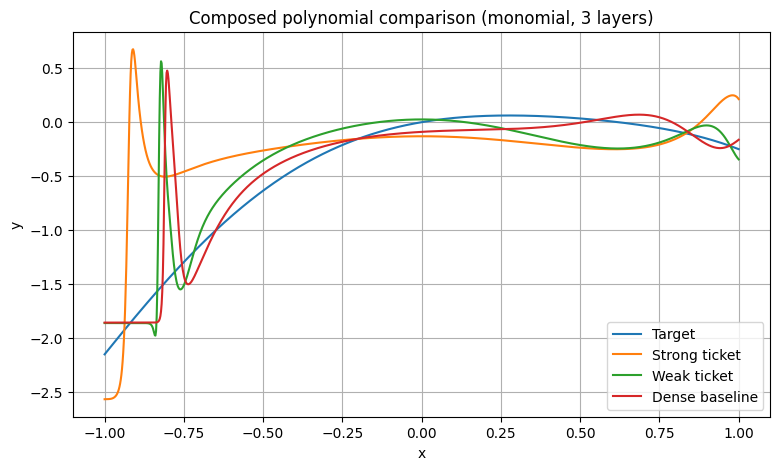

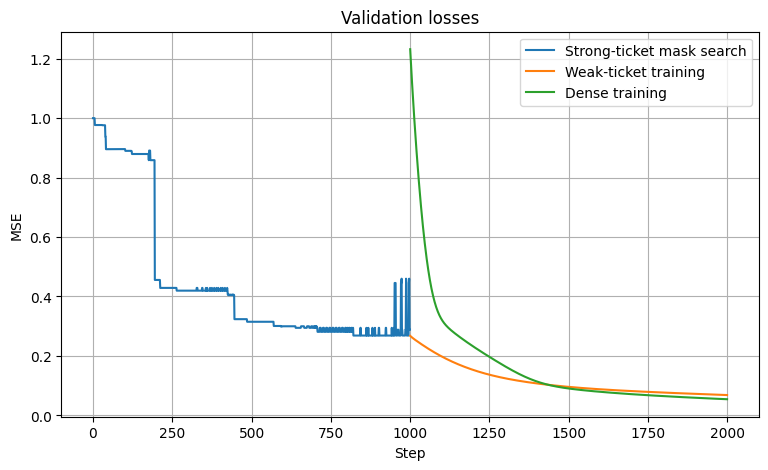

In [12]:
# Colab-ready experiment:
# Double-scoring edge-popup for compositions of frozen random polynomials
# with selectable basis: monomial / legendre / chebyshev.
#
# Added:
#   1. weak-ticket verification: freeze extracted masks, then train coefficients
#   2. dense baseline: same architecture, all coefficients trainable
#   3. comparison plots for target/strong/weak/dense + loss curves
# Removed:
#   - coefficient and mask stem plots

import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# Reproducibility / device
# ============================================================

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# Straight-through TopK mask
# ============================================================

class TopKMaskSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, scores, k):
        if scores.ndim != 1:
            raise ValueError(f"scores must be 1D, got {tuple(scores.shape)}")

        n = scores.numel()
        keep = int(round(k * n))
        keep = max(0, min(keep, n))

        mask = torch.zeros_like(scores)

        if keep == 0:
            return mask
        if keep == n:
            mask.fill_(1.0)
            return mask

        idx = torch.topk(scores, k=keep, largest=True, sorted=False).indices
        mask[idx] = 1.0
        return mask

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None


def topk_mask(scores, k):
    return TopKMaskSTE.apply(scores, k)


# ============================================================
# Initialization
# ============================================================

def signed_kaiming_constant_(shape, nonlinearity="relu", a=0.0, device=None):
    """
    Ramanujan-style signed Kaiming constant initialization
    adapted to a 1D coefficient vector.
    """
    if len(shape) != 1:
        raise ValueError("Expected 1D shape.")

    fan_in = shape[0]
    gain = nn.init.calculate_gain(nonlinearity, a)
    magnitude = gain / math.sqrt(fan_in)

    signs = torch.randint(0, 2, shape, device=device, dtype=torch.float32)
    signs = 2.0 * signs - 1.0
    return magnitude * signs


# ============================================================
# Polynomial bases
# ============================================================

def monomial_features(x, degree):
    if x.ndim != 1:
        raise ValueError(f"x must be 1D, got {tuple(x.shape)}")
    return torch.stack([x**j for j in range(degree + 1)], dim=1)


def legendre_features(x, degree):
    if x.ndim != 1:
        raise ValueError(f"x must be 1D, got {tuple(x.shape)}")

    feats = [torch.ones_like(x)]
    if degree == 0:
        return torch.stack(feats, dim=1)

    feats.append(x)
    for n in range(1, degree):
        nxt = ((2 * n + 1) * x * feats[-1] - n * feats[-2]) / (n + 1)
        feats.append(nxt)
    return torch.stack(feats, dim=1)


def chebyshev_features(x, degree):
    if x.ndim != 1:
        raise ValueError(f"x must be 1D, got {tuple(x.shape)}")

    feats = [torch.ones_like(x)]
    if degree == 0:
        return torch.stack(feats, dim=1)

    feats.append(x)
    for _ in range(1, degree):
        nxt = 2 * x * feats[-1] - feats[-2]
        feats.append(nxt)
    return torch.stack(feats, dim=1)


def basis_features(x, degree, basis="legendre"):
    if basis == "monomial":
        return monomial_features(x, degree)
    elif basis == "legendre":
        return legendre_features(x, degree)
    elif basis == "chebyshev":
        return chebyshev_features(x, degree)
    else:
        raise ValueError("basis must be 'monomial', 'legendre', or 'chebyshev'")


# ============================================================
# One frozen polynomial block with double scoring
# ============================================================

class FrozenMaskedPolynomial(nn.Module):
    """
    Scalar -> scalar polynomial block
    y = sum_j a_j phi_j(x),
    where a_j are frozen and the mask is produced by double scoring.
    """
    def __init__(
        self,
        degree,
        basis="legendre",
        coeff_init="signed_kaiming",
        coeff_scale=0.01,
        k=0.5,
        score_init_scale=1e-2,
        nonlinearity="relu",
        a=0.0,
        force_nontrivial_mask=False,
    ):
        super().__init__()
        self.degree = degree
        self.num_coeffs = degree + 1
        self.basis = basis
        self.k = k
        self.force_nontrivial_mask = force_nontrivial_mask

        if coeff_init == "signed_kaiming":
            coeffs = signed_kaiming_constant_(
                (self.num_coeffs,),
                nonlinearity=nonlinearity,
                a=a,
                device=device,
            )
        elif coeff_init == "randn":
            coeffs = torch.randn(self.num_coeffs, device=device)
        elif coeff_init == "uniform":
            coeffs = 2 * torch.rand(self.num_coeffs, device=device) - 1
        else:
            raise ValueError("coeff_init must be 'signed_kaiming', 'randn', or 'uniform'")

        coeffs = coeff_scale * coeffs
        self.coeffs = nn.Parameter(coeffs, requires_grad=False)

        self.scores_1 = nn.Parameter(score_init_scale * torch.randn(self.num_coeffs, device=device))
        self.scores_2 = nn.Parameter(score_init_scale * torch.randn(self.num_coeffs, device=device))

    def augmented_scores(self):
        return torch.cat([self.scores_1, self.scores_2], dim=0)

    def effective_mask(self):
        full_mask = topk_mask(self.augmented_scores(), self.k)
        mask = full_mask[: self.num_coeffs].clone()

        # avoid total collapse to zero
        if self.force_nontrivial_mask and mask.sum() == 0:
            idx = torch.argmax(self.scores_1)
            mask[idx] = 1.0

        return mask

    def masked_coeffs(self):
        return self.coeffs * self.effective_mask()

    def forward(self, x):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        elif x.ndim != 1:
            raise ValueError(f"x must have shape (batch,) or (batch,1), got {tuple(x.shape)}")

        Phi = basis_features(x, self.degree, basis=self.basis)
        return Phi @ self.masked_coeffs()


# ============================================================
# Composition model with tanh stabilization (strong ticket search)
# ============================================================

class ComposedPolynomialLotteryTicket(nn.Module):
    """
    Composition of frozen masked polynomial blocks:
        x -> p_L(tanh(p_{L-1}( ... tanh(p_1(x)) ... )))
    """
    def __init__(
        self,
        num_layers,
        degree,
        basis="legendre",
        coeff_init="signed_kaiming",
        coeff_scale=0.01,
        k=0.5,
        score_init_scale=1e-2,
        force_nontrivial_mask=False,
        use_tanh_between_layers=True,
    ):
        super().__init__()
        self.use_tanh_between_layers = use_tanh_between_layers
        self.layers = nn.ModuleList([
            FrozenMaskedPolynomial(
                degree=degree,
                basis=basis,
                coeff_init=coeff_init,
                coeff_scale=coeff_scale,
                k=k,
                score_init_scale=score_init_scale,
                force_nontrivial_mask=force_nontrivial_mask,
            )
            for _ in range(num_layers)
        ])

    def forward(self, x):
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            if self.use_tanh_between_layers and i < len(self.layers) - 1:
                out = torch.tanh(out)
        return out

    def score_parameters(self):
        params = []
        for layer in self.layers:
            params.extend([layer.scores_1, layer.scores_2])
        return params

    def masks(self):
        return [layer.effective_mask().detach().cpu() for layer in self.layers]


# ============================================================
# Same architecture, but coefficients trainable under fixed masks
# ============================================================

class FixedMaskPolynomialLayer(nn.Module):
    def __init__(self, init_coeffs, mask, basis="legendre"):
        super().__init__()
        self.degree = init_coeffs.numel() - 1
        self.basis = basis
        self.coeffs = nn.Parameter(init_coeffs.clone())
        self.register_buffer("mask", mask.clone().float())

    def forward(self, x):
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        Phi = basis_features(x, self.degree, basis=self.basis)
        return Phi @ (self.coeffs * self.mask)


class ComposedPolynomialFixedMask(nn.Module):
    """
    Same composed architecture, but the masks are fixed and coefficients train.
    Used for weak-ticket verification.
    """
    def __init__(self, frozen_model):
        super().__init__()
        self.use_tanh_between_layers = frozen_model.use_tanh_between_layers
        self.layers = nn.ModuleList([
            FixedMaskPolynomialLayer(
                init_coeffs=layer.coeffs.detach(),
                mask=layer.effective_mask().detach(),
                basis=layer.basis,
            )
            for layer in frozen_model.layers
        ])

    def forward(self, x):
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            if self.use_tanh_between_layers and i < len(self.layers) - 1:
                out = torch.tanh(out)
        return out


class ComposedPolynomialDenseTrainable(nn.Module):
    """
    Same composed architecture, but all coefficients are trainable (mask = all ones).
    Used as dense baseline.
    """
    def __init__(self, frozen_model):
        super().__init__()
        self.use_tanh_between_layers = frozen_model.use_tanh_between_layers
        self.layers = nn.ModuleList([
            FixedMaskPolynomialLayer(
                init_coeffs=layer.coeffs.detach(),
                mask=torch.ones_like(layer.coeffs.detach()),
                basis=layer.basis,
            )
            for layer in frozen_model.layers
        ])

    def forward(self, x):
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            if self.use_tanh_between_layers and i < len(self.layers) - 1:
                out = torch.tanh(out)
        return out


# ============================================================
# Training utilities
# ============================================================

def train_score_model(
    model,
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    steps=4000,
    verbose_every=500,
    grad_clip=None,
):
    optimizer = torch.optim.Adam(model.score_parameters())

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_state = None
    best_metric = float("inf")

    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train)
        loss = F.mse_loss(pred, y_train)

        if not torch.isfinite(loss):
            print(f"Non-finite loss encountered at step {step}: {loss.item()}")
            break

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.score_parameters(), max_norm=grad_clip)

        optimizer.step()

        with torch.no_grad():
            train_loss = loss.item()
            history["train_loss"].append(train_loss)

            if x_val is not None and y_val is not None:
                model.eval()
                val_pred = model(x_val)
                val_loss = F.mse_loss(val_pred, y_val).item()
            else:
                val_loss = train_loss

            history["val_loss"].append(val_loss)

            if val_loss < best_metric:
                best_metric = val_loss
                best_state = {
                    k: v.detach().clone()
                    for k, v in model.state_dict().items()
                }

        if verbose_every is not None and (step % verbose_every == 0 or step == steps - 1):
            active_counts = [int(m.sum().item()) for m in model.masks()]
            print(
                f"[strong] step={step:5d}  train={train_loss:.8e}  "
                f"val={val_loss:.8e}  active={active_counts}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def train_weight_model(
    model,
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    steps=4000,
    verbose_every=500,
    grad_clip=None,
    label="model",
):
    optimizer = torch.optim.Adam(model.parameters())

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_state = None
    best_metric = float("inf")

    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train)
        loss = F.mse_loss(pred, y_train)

        if not torch.isfinite(loss):
            print(f"Non-finite loss encountered at step {step}: {loss.item()}")
            break

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        optimizer.step()

        with torch.no_grad():
            train_loss = loss.item()
            history["train_loss"].append(train_loss)

            if x_val is not None and y_val is not None:
                model.eval()
                val_pred = model(x_val)
                val_loss = F.mse_loss(val_pred, y_val).item()
            else:
                val_loss = train_loss

            history["val_loss"].append(val_loss)

            if val_loss < best_metric:
                best_metric = val_loss
                best_state = {
                    k: v.detach().clone()
                    for k, v in model.state_dict().items()
                }

        if verbose_every is not None and (step % verbose_every == 0 or step == steps - 1):
            print(f"[{label}] step={step:5d}  train={train_loss:.8e}  val={val_loss:.8e}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


# ============================================================
# Target functions
# ============================================================

def target_function(x, mode="nested"):
    if mode == "sin":
        return torch.sin(2 * math.pi * x)
    elif mode == "poly":
        return 0.5 * x - 1.2 * x**2 + 0.75 * x**3 - 0.3 * x**5
    elif mode == "nested":
        return torch.sin(3.0 * torch.tanh(2.0 * x))
    else:
        raise ValueError("mode must be 'sin', 'poly', or 'nested'")


# ============================================================
# Experiment config
# ============================================================

basis = "monomial"         # "monomial", "legendre", or "chebyshev"
target_mode = "poly"     # "sin", "poly", or "nested"
num_layers = 3
degree = 40
k = 0.5
coeff_scale = 1.0

n_train = 2048
n_val = 2048
n_test = 1024

x_train = torch.linspace(-1.0, 1.0, n_train, device=device)
x_val   = torch.linspace(-1.0, 1.0, n_val, device=device)
x_test  = torch.linspace(-1.0, 1.0, n_test, device=device)

y_train = target_function(x_train, mode=target_mode)
y_val   = target_function(x_val, mode=target_mode)
y_test  = target_function(x_test, mode=target_mode)

# ============================================================
# Strong ticket search
# ============================================================

strong_model = ComposedPolynomialLotteryTicket(
    num_layers=num_layers,
    degree=degree,
    basis=basis,
    coeff_init="uniform",
    coeff_scale=coeff_scale,
    k=k,
    score_init_scale=1.0,
    force_nontrivial_mask=False,
    use_tanh_between_layers=True,
).to(device)

strong_history = train_score_model(
    strong_model,
    x_train,
    y_train,
    x_val=x_val,
    y_val=y_val,
    steps=1000,
    verbose_every=None,
    grad_clip=None,
)

with torch.no_grad():
    strong_model.eval()
    y_pred_strong = strong_model(x_test)
    strong_test_loss = F.mse_loss(y_pred_strong, y_test).item()


# ============================================================
# Weak ticket verification
# ============================================================

weak_model = ComposedPolynomialFixedMask(strong_model).to(device)

weak_history = train_weight_model(
    weak_model,
    x_train,
    y_train,
    x_val=x_val,
    y_val=y_val,
    steps=1000,
    verbose_every=None,
    grad_clip=None,
    label="weak",
)

with torch.no_grad():
    weak_model.eval()
    y_pred_weak = weak_model(x_test)
    weak_test_loss = F.mse_loss(y_pred_weak, y_test).item()


# ============================================================
# Dense baseline
# ============================================================

dense_model = ComposedPolynomialDenseTrainable(strong_model).to(device)

dense_history = train_weight_model(
    dense_model,
    x_train,
    y_train,
    x_val=x_val,
    y_val=y_val,
    steps=1000,
    verbose_every=None,
    grad_clip=None,
    label="dense",
)

with torch.no_grad():
    dense_model.eval()
    y_pred_dense = dense_model(x_test)
    dense_test_loss = F.mse_loss(y_pred_dense, y_test).item()

# ============================================================
# Summary
# ============================================================

print("\nSummary")
print("-------")
print(f"Strong-ticket test MSE: {strong_test_loss:.8e}")
print(f"Weak-ticket  test MSE: {weak_test_loss:.8e}")
print(f"Dense        test MSE: {dense_test_loss:.8e}")


# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(x_test.cpu().numpy(), y_test.cpu().numpy(), label="Target")
plt.plot(x_test.cpu().numpy(), y_pred_strong.detach().cpu().numpy(), label="Strong ticket")
plt.plot(x_test.cpu().numpy(), y_pred_weak.detach().cpu().numpy(), label="Weak ticket")
plt.plot(x_test.cpu().numpy(), y_pred_dense.detach().cpu().numpy(), label="Dense baseline")
plt.legend()
plt.title(f"Composed polynomial comparison ({basis}, {num_layers} layers)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot([i for i in range(len(strong_history["val_loss"]))],strong_history["val_loss"], label="Strong-ticket mask search")
plt.plot([i + len(strong_history["val_loss"]) for i in range(len(weak_history["val_loss"]))],weak_history["val_loss"], label="Weak-ticket training")
plt.plot([i + len(strong_history["val_loss"]) for i in range(len(dense_history["val_loss"]))], dense_history["val_loss"], label="Dense training")
# plt.yscale("log")
plt.title("Validation losses")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()